In [1]:
import warnings
warnings.filterwarnings('ignore')
import os

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
#Functions for printing R^2 and RMSE metrics for both train and test data

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_regression_model(model, Xtr, Xte, ytr, yte, label, results_list):
    model.fit(Xtr, ytr)

    y_train_pred = model.predict(Xtr)
    y_test_pred = model.predict(Xte)

    train_r2 = r2_score(ytr, y_train_pred)
    test_r2 = r2_score(yte, y_test_pred)
    train_rmse = rmse(ytr, y_train_pred)
    test_rmse = rmse(yte, y_test_pred)

    print(f'=== {label} ===')
    print(f'Train R² : {train_r2:.6f}')
    print(f'Test R²  : {test_r2:.6f}')
    print(f'Train RMSE: {train_rmse:.6f}')
    print(f'Test RMSE : {test_rmse:.6f}')
    print(f'R² gap    : {train_r2 - test_r2:.6f}')
    print(f'RMSE gap  : {test_rmse - train_rmse:.6f}')

    results_list.append({
        'Model': label,
        'R2 Train': train_r2,
        'R2 Test': test_r2,
        'RMSE Train': train_rmse,
        'RMSE': test_rmse,
        'Source': 'Default' if '(Tuned)' not in label else 'Tuned'
    })

    return model, y_train_pred, y_test_pred


# Team 03 – Regression Modeling

### 1. Load Data (5 pts)

Load the four CSV files from Notebook 03.  
* Confirm column alignment with an assert statement.  
* Shapes of X train and X test
  X_train (768 x 8)
  X_test  (154 x 8)
* Target range (regression)
  6.01 to 43.10
* Using scaled data for models:
  Linear, Ridge, and Lasso
* Using unscaled data for models:
  Decision tree, Random Forest, Gradient Boosting

In [3]:
#Data load option A (Matthan)
df = pd.read_csv('../data/raw/ee.csv')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

X_train = X_train.drop('cooling_load', axis=1)
X_test = X_test.drop('cooling_load', axis=1)

assert list(X_train.columns) == list(X_test.columns), 'Train/test columns are not aligned.'

print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 768 rows x 8 columns
y_train Loaded: 768 rows x 1 columns
X_test Loaded: 154 rows x 8 columns
y_test Loaded: 154 rows x 1 columns


In [7]:
#Data load option B (Brandon)
#os.chdir('/home/jovyan/DS Capstone')
#print("New working directory:", os.getcwd())

df = pd.read_csv('../data/raw/ee.csv')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

X_train = X_train.drop('cooling_load', axis=1)
X_test = X_test.drop('cooling_load', axis=1)

assert list(X_train.columns) == list(X_test.columns), 'Train/test columns are not aligned.'

print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 768 rows x 8 columns
y_train Loaded: 768 rows x 1 columns
X_test Loaded: 154 rows x 8 columns
y_test Loaded: 154 rows x 1 columns


In [8]:
X_train.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [9]:
y_train.head()

,heating_load
0,15.55
1,15.55
2,15.55
3,15.55
4,20.84


In [10]:
print('\nTarget range')
print(f'y_train min={y_train["heating_load"].min():.2f}, max={y_train["heating_load"].max():.2f}')
print(f'y_test min={y_test["heating_load"].min():.2f}, max={y_test["heating_load"].max():.2f}')


Target range
y_train min=6.01, max=43.10
y_test min=6.37, max=42.96


In [11]:
# Create scaled copies of the predictor matrices for linear models only
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Scaled X_train means:')
print(X_train_scaled.mean().round(4).head())
print('\nScaled X_train std devs:')
print(X_train_scaled.std().round(4).head())


Scaled X_train means:
relative_compactness   -0.0
surface_area           -0.0
wall_area               0.0
roof_area               0.0
overall_height          0.0
dtype: float64

Scaled X_train std devs:
relative_compactness    1.0007
surface_area            1.0007
wall_area               1.0007
roof_area               1.0007
overall_height          1.0007
dtype: float64


### 2. All Models - Default Parameters

* Fit every required model with default hyperparameters.
* Initialise one empty list (results = [])
at the top of this section and append a result dictionary after every model.
* For each model: train, predict, and print metrics.
* Compare training and test metrics side by side to check for overfitting

In [12]:
results = []

#### Model 1: Linear Regression, unscaled data

In [13]:
lr_unscaled = LinearRegression()
lr_unscaled, y_train_pred_lr_unscaled, y_test_pred_lr_unscaled = evaluate_regression_model(
    lr_unscaled, X_train, X_test, y_train, y_test, 'Linear Regression (Unscaled)', results
)

=== Linear Regression (Unscaled) ===
Train R² : 0.916202
Test R²  : 0.912750
Train RMSE: 2.918994
Test RMSE : 3.015661
R² gap    : 0.003452
RMSE gap  : 0.096667


#### Model 2: Linear Regression, scaled data

In [14]:
lr_scaled = LinearRegression()
lr_scaled, y_train_pred_lr_scaled, y_test_pred_lr_scaled = evaluate_regression_model(
    lr_scaled, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression (Scaled)', results
)

=== Linear Regression (Scaled) ===
Train R² : 0.916202
Test R²  : 0.912750
Train RMSE: 2.918994
Test RMSE : 3.015661
R² gap    : 0.003452
RMSE gap  : 0.096667


#### Model 3: Ridge Regression, scaled

In [15]:
ridge_default = Ridge(alpha=1.0, random_state=4950)
ridge_default, y_train_pred_ridge, y_test_pred_ridge = evaluate_regression_model(
    ridge_default, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression', results
)

=== Ridge Regression ===
Train R² : 0.916100
Test R²  : 0.912359
Train RMSE: 2.920776
Test RMSE : 3.022410
R² gap    : 0.003741
RMSE gap  : 0.101633


### Model 4: Lasso Regression

In [16]:
lasso_default = Lasso(alpha=0.01, random_state=4950, max_iter=10000)
lasso_default, y_train_pred_lasso, y_test_pred_lasso = evaluate_regression_model(
    lasso_default, X_train_scaled, X_test_scaled, y_train, y_test, 'Lasso Regression', results
)

lasso_coef = pd.Series(lasso_default.coef_, index=X_train.columns)
print('\nLasso coefficients:')
print(lasso_coef.sort_values(key=np.abs, ascending=False))
print(f'\nNumber of zeroed coefficients: {(lasso_coef == 0).sum()}')


=== Lasso Regression ===
Train R² : 0.915827
Test R²  : 0.911985
Train RMSE: 2.925513
Test RMSE : 3.028860
R² gap    : 0.003843
RMSE gap  : 0.103346

Lasso coefficients:
overall_height          7.980642
roof_area              -4.868154
relative_compactness   -4.851931
glazing_area            2.645469
glazing_area_dist       0.307592
surface_area           -0.302834
orientation            -0.016082
wall_area              -0.000000
dtype: float64

Number of zeroed coefficients: 1


#### Model 5: Decision Tree

In [17]:
dt_default = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt_default, y_train_pred_dt, y_test_pred_dt = evaluate_regression_model(
    dt_default, X_train, X_test, y_train, y_test, 'Decision Tree', results
)

=== Decision Tree ===
Train R² : 0.999735
Test R²  : 0.999649
Train RMSE: 0.164303
Test RMSE : 0.191277
R² gap    : 0.000086
RMSE gap  : 0.026974


#### Model 6: Random Forest

In [18]:
rf_default = RandomForestRegressor(n_estimators=100, random_state=4950)
rf_default, y_train_pred_rf, y_test_pred_rf = evaluate_regression_model(
    rf_default, X_train, X_test, y_train, y_test, 'Random Forest', results
)

=== Random Forest ===
Train R² : 0.999731
Test R²  : 0.999724
Train RMSE: 0.165334
Test RMSE : 0.169734
R² gap    : 0.000008
RMSE gap  : 0.004400


#### Model 7: Gradient Boosting

In [19]:
gb_default = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=4950)
gb_default, y_train_pred_gb, y_test_pred_gb = evaluate_regression_model(
    gb_default, X_train, X_test, y_train, y_test, 'Gradient Boosting', results
)

=== Gradient Boosting ===
Train R² : 0.998237
Test R²  : 0.998012
Train RMSE: 0.423355
Test RMSE : 0.455149
R² gap    : 0.000225
RMSE gap  : 0.031794


#### Model comparison



In [20]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df['Source'] == 'Default'].sort_values('R2 Test', ascending=False)
results_df


,Model,R2 Train,R2 Test,RMSE Train,RMSE,Source
5,Random Forest,0.999731,0.999724,0.165334,0.169734,Default
4,Decision Tree,0.999735,0.999649,0.164303,0.191277,Default
6,Gradient Boosting,0.998237,0.998012,0.423355,0.455149,Default
0,Linear Regression (Unscaled),0.916202,0.912750,2.918994,3.015661,Default
1,Linear Regression (Scaled),0.916202,0.912750,2.918994,3.015661,Default
2,Ridge Regression,0.916100,0.912359,2.920776,3.022410,Default
3,Lasso Regression,0.915827,0.911985,2.925513,3.028860,Default


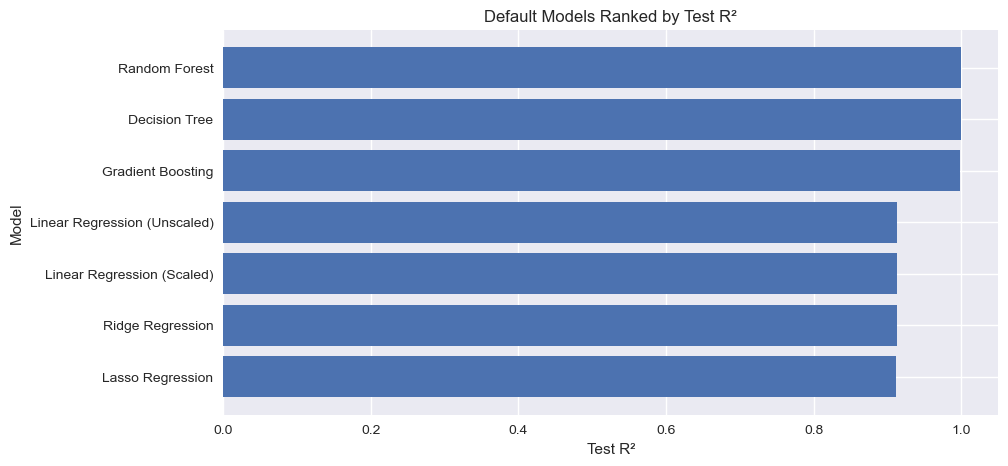

In [21]:
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['R2 Test'])
plt.xlabel('Test R²')
plt.ylabel('Model')
plt.title('Default Models Ranked by Test R²')
plt.gca().invert_yaxis()
plt.show()


### Best Performer?
Random forest has the best R squared, albeit only by the slightest amounts. As for overfitting, there's very slight differences between Train and Test, so I'd say no models were overfit. Continuing with tuning ridge, random forest, and gradient boosting.

### 3. Cross-Validation (20 pts)
Run 5-fold cross-validation on all models using the CV object defined above. Use scoring="roc auc"
for classification and scoring="r2" for regression.
Deliver:
* CV mean and std for every model, printed after each cross val score call
* A summary DataFrame with columns: Model, CV Mean, CV Std, and all 5 fold scores
* A horizontal bar chart with error bars (xerr = CV Std), sorted by CV Mean.
* Write a markdown cell addressing: Do CV means agree with the test-set results from Section 2?
Flag any model with CV Std > 0.03 as potentially unstable.

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=4950)
print(cv)


KFold(n_splits=5, random_state=4950, shuffle=True)


In [23]:
cv_models = {
    'Linear Regression, Unscaled': LinearRegression(),
    'Linear Regression, Scaled': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=4950)),
    'Lasso Regression': make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=4950, max_iter=10000)),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=4950),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=4950),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=4950)
}

cv_rows = []

for model_name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    print(f'{model_name}')
    print(f'  CV mean = {scores.mean():.6f}')
    print(f'  CV std  = {scores.std():.6f}')
    print(f'  folds   = {np.round(scores, 6)}\n')

    row = {
        'Model': model_name,
        'CV Mean': scores.mean(),
        'CV Std': scores.std()
    }
    for i, score in enumerate(scores, start=1):
        row[f'Fold {i}'] = score
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values('CV Mean', ascending=False)
cv_results_df


Linear Regression, Unscaled
  CV mean = 0.912717
  CV std  = 0.015937
  folds   = [0.919651 0.886462 0.925048 0.90287  0.929555]

Linear Regression, Scaled
  CV mean = 0.912717
  CV std  = 0.015937
  folds   = [0.919651 0.886462 0.925048 0.90287  0.929555]

Ridge Regression
  CV mean = 0.912649
  CV std  = 0.015647
  folds   = [0.919734 0.887305 0.924853 0.902179 0.929173]

Lasso Regression
  CV mean = 0.912393
  CV std  = 0.015606
  folds   = [0.919325 0.886924 0.924363 0.902332 0.92902 ]

Decision Tree
  CV mean = 0.996960
  CV std  = 0.000465
  folds   = [0.996388 0.996893 0.996729 0.996996 0.997794]

Random Forest
  CV mean = 0.997551
  CV std  = 0.000561
  folds   = [0.99754  0.996503 0.997821 0.997732 0.998159]

Gradient Boosting
  CV mean = 0.997827
  CV std  = 0.000246
  folds   = [0.998085 0.997567 0.997654 0.997669 0.998163]



,Model,CV Mean,CV Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
6,Gradient Boosting,0.997827,0.000246,0.998085,0.997567,0.997654,0.997669,0.998163
5,Random Forest,0.997551,0.000561,0.997540,0.996503,0.997821,0.997732,0.998159
4,Decision Tree,0.996960,0.000465,0.996388,0.996893,0.996729,0.996996,0.997794
0,"Linear Regression, Unscaled",0.912717,0.015937,0.919651,0.886462,0.925048,0.902870,0.929555
1,"Linear Regression, Scaled",0.912717,0.015937,0.919651,0.886462,0.925048,0.902870,0.929555
2,Ridge Regression,0.912649,0.015647,0.919734,0.887305,0.924853,0.902179,0.929173
3,Lasso Regression,0.912393,0.015606,0.919325,0.886924,0.924363,0.902332,0.929020


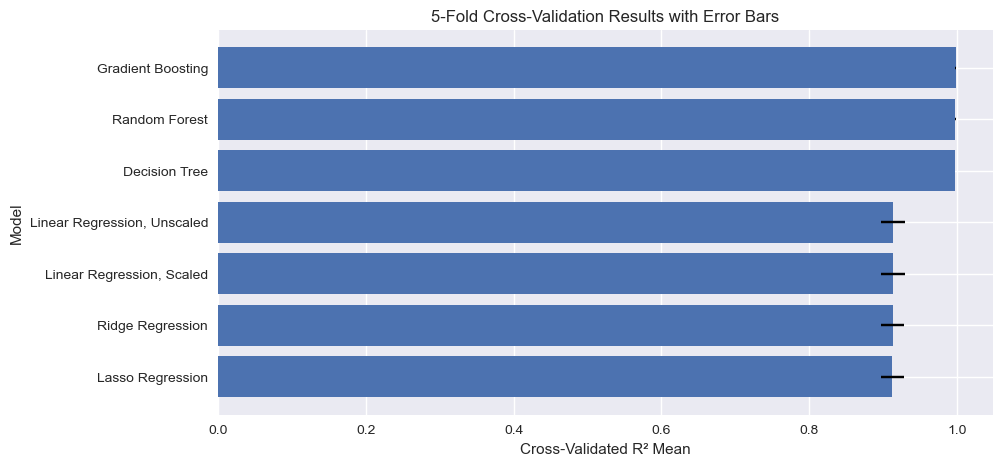

In [24]:
plt.figure(figsize=(10, 5))
plt.barh(cv_results_df['Model'], cv_results_df['CV Mean'], xerr=cv_results_df['CV Std'])
plt.xlabel('Cross-Validated R² Mean')
plt.ylabel('Model')
plt.title('5-Fold Cross-Validation Results with Error Bars')
plt.gca().invert_yaxis()
plt.show()


In [25]:
cv_results_df['Potentially Unstable'] = cv_results_df['CV Std'] > 0.03
cv_results_df[['Model', 'CV Mean', 'CV Std', 'Potentially Unstable']]


,Model,CV Mean,CV Std,Potentially Unstable
6,Gradient Boosting,0.997827,0.000246,False
5,Random Forest,0.997551,0.000561,False
4,Decision Tree,0.996960,0.000465,False
0,"Linear Regression, Unscaled",0.912717,0.015937,False
1,"Linear Regression, Scaled",0.912717,0.015937,False
2,Ridge Regression,0.912649,0.015647,False
3,Lasso Regression,0.912393,0.015606,False


No potentially unstable models, means agree when compared to test data.

### 4. Hyperparameter Tuning — GridSearchCV (30 pts)
Tune at least three models using GridSearchCV with the same CV object from Section 3. Append
every tuned result to the same results list with a label such as “Random Forest (Tuned)”.
* Tuning Ridge Regression, Random forest, and Gradient Boosting.


### Tuning 1: Ridge Regression
alpha: [0.001, 0.01, 0.1, 1, 10, 100, 1000]

In [26]:
ridge_param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), Ridge(random_state=4950)),
    param_grid=ridge_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    return_train_score=True
)

ridge_grid.fit(X_train, y_train)

ridge_cv_df = pd.DataFrame(ridge_grid.cv_results_)[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'param_ridge__alpha'
]].sort_values('rank_test_score')

print('Best parameters:', ridge_grid.best_params_)
print(f'Best CV mean: {ridge_grid.best_score_:.6f}')
print('\nTop 5 CV combinations:')
print(ridge_cv_df.head(5).to_string(index=False))


Best parameters: {'ridge__alpha': 0.1}
Best CV mean: 0.912724

Top 5 CV combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_ridge__alpha
               1         0.912724        0.015901          0.916438               0.100
               2         0.912718        0.015933          0.916441               0.010
               3         0.912717        0.015937          0.916441               0.001
               4         0.912649        0.015647          0.916293               1.000
               5         0.910337        0.015183          0.913576              10.000


In [27]:
ridge_best = ridge_grid.best_estimator_
ridge_cv_scores = cross_val_score(ridge_best, X_train, y_train, cv=cv, scoring='r2')

print('Best estimator CV scores:', np.round(ridge_cv_scores, 6))
print(f'CV mean = {ridge_cv_scores.mean():.6f}')
print(f'CV std  = {ridge_cv_scores.std():.6f}\n')

ridge_best, _, _ = evaluate_regression_model(
    ridge_best, X_train, X_test, y_train, y_test, 'Ridge Regression (Tuned)', results
)


Best estimator CV scores: [0.919668 0.886568 0.925029 0.902824 0.929531]
CV mean = 0.912724
CV std  = 0.015901

=== Ridge Regression (Tuned) ===
Train R² : 0.916201
Test R²  : 0.912715
Train RMSE: 2.919021
Test RMSE : 3.016257
R² gap    : 0.003485
RMSE gap  : 0.097237


### Tuning 2: Random Forest
max depth, max features

In [28]:
rf_param_grid = {
    'max_depth': [5, 10, 15, None],
    'max_features': [1.0, 'sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=100, random_state=4950),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

rf_cv_df = pd.DataFrame(rf_grid.cv_results_)[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_max_depth', 'param_max_features'
]].sort_values('rank_test_score')

print('Best params:', rf_grid.best_params_)
print(f'Best CV mean: {rf_grid.best_score_:.6f}')
print('\nTop 5 CV combinations:')
print(rf_cv_df.head(5).to_string(index=False))


Best params: {'max_depth': 15, 'max_features': 1.0}
Best CV mean: 0.997551

Top 5 CV combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score param_max_depth param_max_features
               1         0.997551        0.000561          0.999651              15                1.0
               1         0.997551        0.000561          0.999651            None                1.0
               3         0.997526        0.000579          0.999569              10                1.0
               4         0.996945        0.001222          0.999562              15               log2
               4         0.996945        0.001222          0.999562            None               log2


In [29]:
rf_best = rf_grid.best_estimator_
rf_cv_scores = cross_val_score(rf_best, X_train, y_train, cv=cv, scoring='r2')

print('Best estimator CV scores:', np.round(rf_cv_scores, 6))
print(f'CV mean = {rf_cv_scores.mean():.6f}')
print(f'CV std  = {rf_cv_scores.std():.6f}\n')

rf_best, _, _ = evaluate_regression_model(
    rf_best, X_train, X_test, y_train, y_test, 'Random Forest (Tuned)', results
)


Best estimator CV scores: [0.99754  0.996503 0.997821 0.997732 0.998159]
CV mean = 0.997551
CV std  = 0.000561

=== Random Forest (Tuned) ===
Train R² : 0.999731
Test R²  : 0.999724
Train RMSE: 0.165334
Test RMSE : 0.169734
R² gap    : 0.000008
RMSE gap  : 0.004400


### Tuning 3: Gradient Boosting
n estimators, learning rate, max depth

In [30]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=4950),
    param_grid=gb_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    return_train_score=True
)

gb_grid.fit(X_train, y_train)

gb_cv_df = pd.DataFrame(gb_grid.cv_results_)[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_n_estimators', 'param_learning_rate', 'param_max_depth'
]].sort_values('rank_test_score')

print('Best parameters:', gb_grid.best_params_)
print(f'Best CV mean: {gb_grid.best_score_:.6f}')
print('\nTop 5 CV combinations:')
print(gb_cv_df.head(5).to_string(index=False))


Best parameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
Best CV mean: 0.998852

Top 5 CV combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_n_estimators  param_learning_rate  param_max_depth
               1         0.998852        0.000144          0.999711                 200                  0.2                4
               2         0.998748        0.000197          0.999503                 100                  0.2                4
               3         0.998700        0.000226          0.999475                 200                  0.1                4
               4         0.998524        0.000215          0.999212                 200                  0.2                3
               5         0.998393        0.000386          0.999017                 100                  0.1                4


In [31]:
gb_best = gb_grid.best_estimator_
gb_cv_scores = cross_val_score(gb_best, X_train, y_train, cv=cv, scoring='r2')

print('Best estimator CV scores:', np.round(gb_cv_scores, 6))
print(f'CV mean = {gb_cv_scores.mean():.6f}')
print(f'CV std  = {gb_cv_scores.std():.6f}\n')

gb_best, y_train_pred_best, y_test_pred_best = evaluate_regression_model(
    gb_best, X_train, X_test, y_train, y_test, 'Gradient Boosting (Tuned)', results
)


Best estimator CV scores: [0.998947 0.998704 0.99882  0.998709 0.999078]
CV mean = 0.998852
CV std  = 0.000144

=== Gradient Boosting (Tuned) ===
Train R² : 0.999666
Test R²  : 0.999651
Train RMSE: 0.184274
Test RMSE : 0.190796
R² gap    : 0.000015
RMSE gap  : 0.006521


In [32]:
tuning_compare_df = pd.DataFrame(results)
tuning_compare_df[tuning_compare_df['Model'].isin([
    'Ridge Regression', 'Ridge Regression (Tuned)',
    'Random Forest', 'Random Forest (Tuned)',
    'Gradient Boosting', 'Gradient Boosting (Tuned)'
])].sort_values('R2 Test', ascending=False)


,Model,R2 Train,R2 Test,RMSE Train,RMSE,Source
5,Random Forest,0.999731,0.999724,0.165334,0.169734,Default
8,Random Forest (Tuned),0.999731,0.999724,0.165334,0.169734,Tuned
9,Gradient Boosting (Tuned),0.999666,0.999651,0.184274,0.190796,Tuned
6,Gradient Boosting,0.998237,0.998012,0.423355,0.455149,Default
7,Ridge Regression (Tuned),0.916201,0.912715,2.919021,3.016257,Tuned
2,Ridge Regression,0.916100,0.912359,2.920776,3.022410,Default


### 5. Final Model Comparison

In [33]:
results_df_final = pd.DataFrame(results).sort_values('R2 Test', ascending=False)
results_df_final


,Model,R2 Train,R2 Test,RMSE Train,RMSE,Source
5,Random Forest,0.999731,0.999724,0.165334,0.169734,Default
8,Random Forest (Tuned),0.999731,0.999724,0.165334,0.169734,Tuned
9,Gradient Boosting (Tuned),0.999666,0.999651,0.184274,0.190796,Tuned
4,Decision Tree,0.999735,0.999649,0.164303,0.191277,Default
6,Gradient Boosting,0.998237,0.998012,0.423355,0.455149,Default
0,Linear Regression (Unscaled),0.916202,0.912750,2.918994,3.015661,Default
1,Linear Regression (Scaled),0.916202,0.912750,2.918994,3.015661,Default
7,Ridge Regression (Tuned),0.916201,0.912715,2.919021,3.016257,Tuned
2,Ridge Regression,0.916100,0.912359,2.920776,3.022410,Default
3,Lasso Regression,0.915827,0.911985,2.925513,3.028860,Default


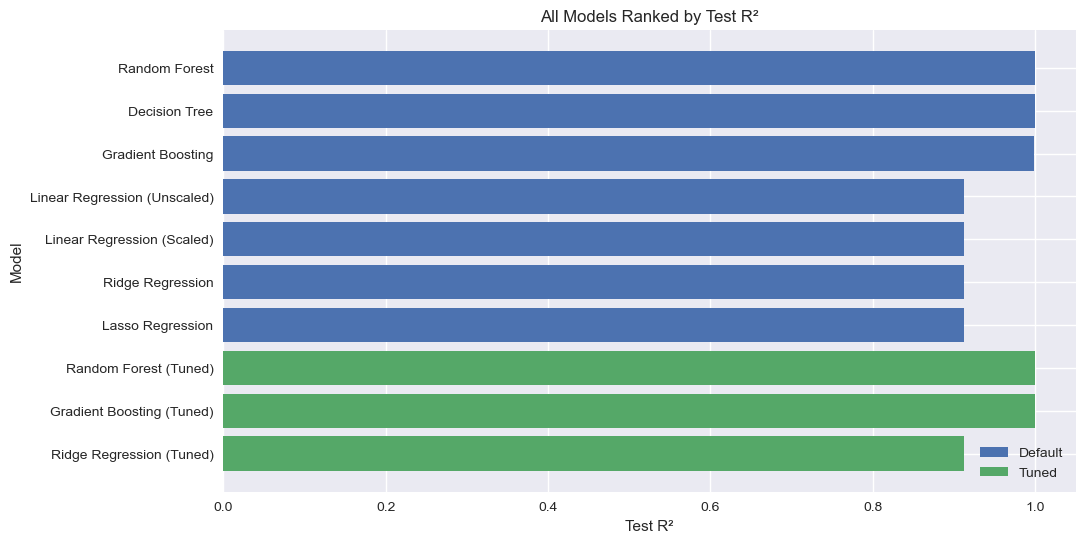

In [34]:
plt.figure(figsize=(11, 6))

default_mask = results_df_final['Source'] == 'Default'
tuned_mask = results_df_final['Source'] == 'Tuned'

plt.barh(results_df_final.loc[default_mask, 'Model'], results_df_final.loc[default_mask, 'R2 Test'], label='Default')
plt.barh(results_df_final.loc[tuned_mask, 'Model'], results_df_final.loc[tuned_mask, 'R2 Test'], label='Tuned')

plt.xlabel('Test R²')
plt.ylabel('Model')
plt.title('All Models Ranked by Test R²')
plt.legend()
plt.gca().invert_yaxis()
plt.show()


In [35]:
# Select the best model based on R^2
model_lookup = {
    'Linear Regression (Unscaled)': lr_unscaled,
    'Linear Regression (Scaled)': lr_scaled,
    'Ridge Regression': ridge_default,
    'Lasso Regression': lasso_default,
    'Decision Tree': dt_default,
    'Random Forest': rf_default,
    'Gradient Boosting': gb_default,
    'Ridge Regression (Tuned)': ridge_best,
    'Random Forest (Tuned)': rf_best,
    'Gradient Boosting (Tuned)': gb_best
}

best_model_name = results_df_final.iloc[0]['Model']
best_model = model_lookup[best_model_name]

print('Best model:  ', best_model_name)
print(results_df_final.iloc[0][['R2 Test', 'RMSE', 'R2 Train', 'RMSE Train']])


Best model:   Random Forest
R2 Test       0.999724
RMSE          0.169734
R2 Train      0.999731
RMSE Train    0.165334
Name: 5, dtype: object


In [36]:
#Calculate predictions for best model
y_testc = y_test.squeeze()
y_trainc = y_train.squeeze()

if best_model_name in ['Linear Regression (Scaled)', 'Ridge Regression', 'Lasso Regression']:
    Xtr_plot = X_train_scaled
    Xte_plot = X_test_scaled
else:
    Xtr_plot = X_train
    Xte_plot = X_test

best_model.fit(Xtr_plot, y_trainc)
best_train_pred = best_model.predict(Xtr_plot)
best_test_pred = best_model.predict(Xte_plot)
best_residuals = y_testc - best_test_pred


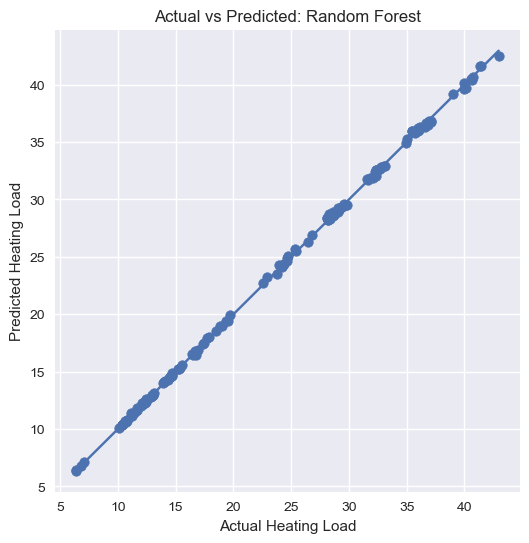

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_test_pred)
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Actual vs Predicted: {best_model_name}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()


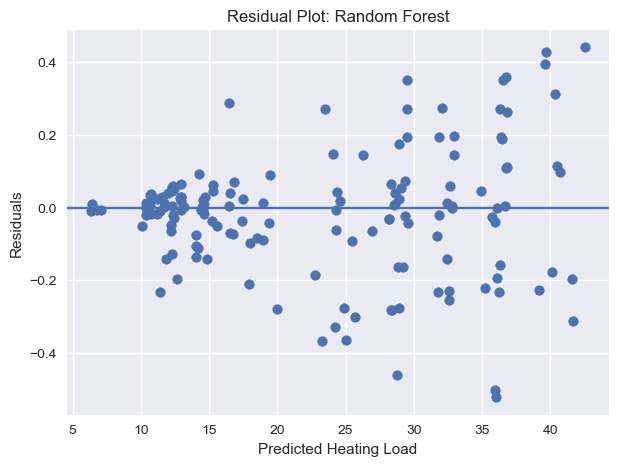

In [38]:
plt.figure(figsize=(7, 5))
plt.scatter(best_test_pred, best_residuals)
plt.axhline(0)
plt.xlabel('Predicted Heating Load')
plt.ylabel('Residuals')
plt.title(f'Residual Plot: {best_model_name}')
plt.show()


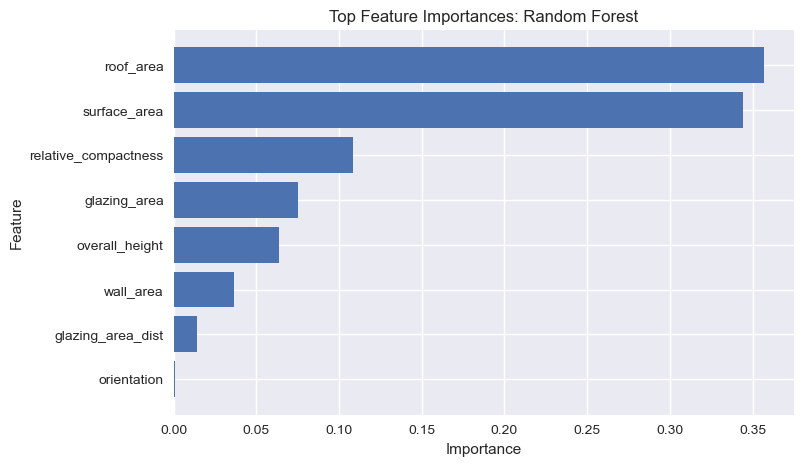

roof_area               0.356949
surface_area            0.344426
relative_compactness    0.108293
glazing_area            0.075222
overall_height          0.063717
wall_area               0.036670
glazing_area_dist       0.013985
orientation             0.000738
dtype: float64


In [39]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
    plt.figure(figsize=(8, 5))
    plt.barh(importances.index, importances.values)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Top Feature Importances: {best_model_name}')
    plt.show()
    print(importances.sort_values(ascending=False))
else:
    coef = pd.Series(best_model.coef_, index=X_train.columns)
    importances = coef.abs().sort_values(ascending=True).tail(15)
    plt.figure(figsize=(8, 5))
    plt.barh(importances.index, importances.values)
    plt.xlabel('Absolute Coefficient')
    plt.ylabel('Feature')
    plt.title(f'Top Absolute Coefficients: {best_model_name}')
    plt.show()
    print(coef.sort_values(key=np.abs, ascending=False))


### Final model selection

In [40]:
cv_lookup = {}

for row in cv_rows:
    cv_lookup[row['Model']] = (row['CV Mean'], row['CV Std'])

# Add tuned-model CV summaries
cv_lookup['Ridge Regression (Tuned)'] = (ridge_cv_scores.mean(), ridge_cv_scores.std())
cv_lookup['Random Forest (Tuned)'] = (rf_cv_scores.mean(), rf_cv_scores.std())
cv_lookup['Gradient Boosting (Tuned)'] = (gb_cv_scores.mean(), gb_cv_scores.std())

best_default_row = results_df_final[results_df_final['Source'] == 'Default'].sort_values('R2 Test', ascending=False).iloc[0]
winning_row = results_df_final.iloc[0]

winning_cv_mean, winning_cv_std = cv_lookup[best_model_name]
improvement_over_best_default = winning_row['R2 Test'] - best_default_row['R2 Test']

print('Best model summary')
print(f"Model: {best_model_name}")
print(f"Test R²: {winning_row['R2 Test']:.6f}")
print(f"Test RMSE: {winning_row['RMSE']:.6f}")
print(f"CV mean ± std: {winning_cv_mean:.6f} ± {winning_cv_std:.6f}")
print(f"Improvement over best default model: {improvement_over_best_default:.6f}")
print(f"Best default model: {best_default_row['Model']}")


Best model summary
Model: Random Forest
Test R²: 0.999724
Test RMSE: 0.169734
CV mean ± std: 0.997551 ± 0.000561
Improvement over best default model: 0.000000
Best default model: Random Forest


Random Forest is selected for best model as it leads the pack in R2 and RMSE.

### 6. Save Best Model (5 pts)
Use pickle to save the winning model to ../models/best model.pkl. Print the model type and
its best parameters. Add a verification cell that loads the file and calls predict() on the first five test rows to confirm the saved model works correctly



In [41]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / 'best_model.pkl'

with open(best_model_path, 'wb') as f:
    pickle.dump(best_model, f)

print('Saved model type:', type(best_model).__name__)
print('Saved to:', best_model_path)

if best_model_name == 'Ridge Regression (Tuned)':
    print('Best parameters:', ridge_grid.best_params_)
elif best_model_name == 'Random Forest (Tuned)':
    print('Best parameters:', rf_grid.best_params_)
elif best_model_name == 'Gradient Boosting (Tuned)':
    print('Best parameters:', gb_grid.best_params_)
else:
    print('Best parameters: default model settings used')


Saved model type: RandomForestRegressor
Saved to: ..\models\best_model.pkl
Best parameters: default model settings used


In [42]:
with open(best_model_path, 'rb') as f:
    loaded_model = pickle.load(f)

if best_model_name in ['Linear Regression (Scaled)', 'Ridge Regression', 'Lasso Regression']:
    verification_X = X_test_scaled.head()
else:
    verification_X = X_test.head()

verification_preds = loaded_model.predict(verification_X)

print('Loaded model type:', type(loaded_model).__name__)
print('First five predictions:')
print(np.round(verification_preds, 6))


Loaded model type: RandomForestRegressor
First five predictions:
[16.4664 13.1684 32.8205 41.6322 16.7623]


## Key Findings Summary


1. Extremely accurate model, accounting for 99.97% of the data.
2. On average, data is off by only .169734. Closer we can get to zero, the better.